# 01 – Data

**Purpose:** Download, check and cache daily prices for the VaR backtest portfolio.
**Portfolio:** SPY (US equities), TLT (long-dated US Treasuries), GLD (gold)
**Output:** `data/prices.csv`, used by every later notebook

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Settings
TICKERS = ["SPY", "TLT", "GLD"] 
DOWNLOAD_START = "2004-11-01"
END = "2026-10-01"

# Locate project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
PRICES_PATH = DATA_DIR / "prices.csv"

## 1. Exploring the yfinance output

In [2]:
spy = yf.download("SPY", start="2024-02-01", end="2024-05-01", auto_adjust=True, progress=False)
print(spy.columns)
spy.head()

MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2024-02-01,473.698334,473.727382,468.469424,469.273140,91891600
2024-02-02,478.685150,480.331263,473.795156,474.134071,99228200
2024-02-05,476.942078,478.714105,474.695616,478.055660,75757100
2024-02-06,478.326874,478.656096,476.458009,477.881429,55918600
2024-02-07,482.316223,482.732590,479.663028,480.563581,70556500


In [3]:
spy_raw = yf.download("SPY", start="2024-02-01", end="2024-05-01", auto_adjust=False, progress=False)
close = spy_raw["Close"].squeeze()
adj_close = spy_raw["Adj Close"].squeeze()
ratio = adj_close / close

comparison = pd.DataFrame({"Close": close, "Adj Close": adj_close, "Ratio": ratio})
change_dates = ratio.index[ratio.diff().abs() > 1e-4]
print("Dates where the adjustment ratio changes:", [d.date() for d in change_dates])

if len(change_dates) > 0:
    i = comparison.index.get_loc(change_dates[0])
    display(comparison.iloc[max(i - 2, 0) : i + 3])

Dates where the adjustment ratio changes: [datetime.date(2024, 3, 15)]


,Close,Adj Close,Ratio
Date,,,
2024-03-13,515.969971,499.620026,0.968312
2024-03-14,514.950012,498.632355,0.968312
2024-03-15,509.829987,495.208405,0.971321
2024-03-18,512.859985,498.151520,0.971321
2024-03-19,515.710022,500.919830,0.971321


## 2. Full download

In [4]:
raw = yf.download(TICKERS, start=DOWNLOAD_START, end=END, auto_adjust=True, progress=False)
if raw.empty:
    raise RuntimeError("yfinance returned no data.")

prices = raw["Close"][TICKERS].copy()
prices.columns.name = None
prices.index.name = "Date"
prices.tail()

,SPY,TLT,GLD
Date,,,
2026-09-24,767.179993,79.101418,391.690002
2026-09-25,771.349976,79.001823,393.410004
2026-09-28,765.609985,78.304634,377.910004
2026-09-29,764.200012,77.916199,382.890015
2026-09-30,762.630005,77.467995,380.839996


## 3. Data quality checks

In [5]:
# Count missing values per ticker (isna gives True/False, and True counts as 1)
print("Missing values per ticker:")
print(prices.isna().sum(), "\n")

# First date each ticker has a valid price
first_valid = prices.apply(lambda s: s.first_valid_index())
print("First valid date per ticker:")
print(first_valid)

Missing values per ticker:
SPY     0
TLT     0
GLD    13
dtype: int64 

First valid date per ticker:
SPY   2004-11-01
TLT   2004-11-01
GLD   2004-11-18
dtype: datetime64[s]


In [6]:
# Find common start date between SPY, TLT, & GLD
common_start = first_valid.max()
prices = prices.loc[common_start:]

remaining = int(prices.isna().sum().sum())
print(f"Common start date: {common_start.date()}")
print(f"Missing values after trimming: {remaining}")
if remaining > 0:
    display(prices[prices.isna().any(axis=1)])

Common start date: 2004-11-18
Missing values after trimming: 0


In [7]:
n_before = len(prices)
prices = prices.dropna()
print(f"Dropped {n_before - len(prices)} rows with missing values.")

Dropped 0 rows with missing values.


In [8]:
# Sanity checks
assert prices.index.is_monotonic_increasing, "Index is not sorted"
assert not prices.index.duplicated().any(), "Duplicate dates found"
assert (prices > 0).all().all(), "Non-positive prices found"
print(f"{len(prices)} trading days from {prices.index[0].date()} to {prices.index[-1].date()}")

prices.groupby(prices.index.year).size()

5500 trading days from 2004-11-18 to 2026-09-30


Date
2004     30
2005    252
2006    251
2007    251
2008    253
2009    252
2010    252
2011    252
2012    250
2013    252
2014    252
2015    252
2016    252
2017    251
2018    251
2019    252
2020    253
2021    252
2022    251
2023    250
2024    252
2025    250
2026    187
dtype: int64

In [9]:
gaps = prices.index.to_series().diff().dt.days
print("Largest gaps (calendar days) between consecutive trading days:")
gaps.nlargest(8)

Largest gaps (calendar days) between consecutive trading days:


Date
2007-01-03    5.0
2012-10-31    5.0
2004-12-27    4.0
2005-01-18    4.0
2005-02-22    4.0
2005-03-28    4.0
2005-05-31    4.0
2005-07-05    4.0
Name: Date, dtype: float64

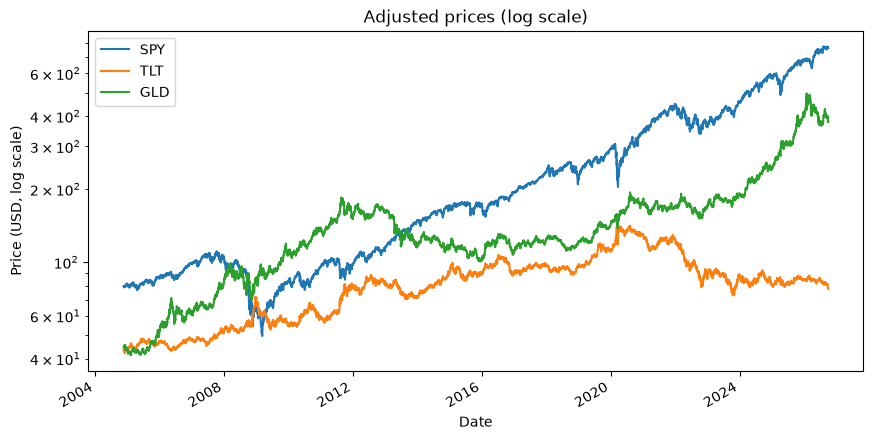

In [10]:
ax = prices.plot(logy=True, figsize=(10, 5), title="Adjusted prices (log scale)")
ax.set_ylabel("Price (USD, log scale)")
plt.show()

In [11]:
# Days with largest percentage-change line up with expected dates
returns = prices.pct_change().dropna()

rows = []
for t in TICKERS:
    for date in returns[t].abs().nlargest(5).index:
        rows.append({"Ticker": t, "Date": date.date(), "Return": f"{returns.at[date, t]:.2%}"})
pd.DataFrame(rows)

,Ticker,Date,Return
0,SPY,2008-10-13,14.52%
1,SPY,2008-10-28,11.69%
2,SPY,2020-03-16,-10.94%
3,SPY,2025-04-09,10.50%
4,SPY,2008-10-15,-9.84%
5,TLT,2020-03-20,7.52%
6,TLT,2020-03-17,-6.67%
7,TLT,2020-03-16,6.48%
8,TLT,2020-03-18,-5.64%
9,TLT,2020-03-06,5.20%


## 4. Save to cache

In [12]:
# Cache the cleaned prices 
prices.to_csv(PRICES_PATH)
print(f"Saved {prices.shape[0]} rows x {prices.shape[1]} columns to {PRICES_PATH}")

Saved 5500 rows x 3 columns to /Users/wainwwi/var_backtest/data/prices.csv


In [13]:
def load_prices(path=PRICES_PATH):
    """Load cached adjusted prices with a DatetimeIndex."""
    df = pd.read_csv(path, index_col="Date", parse_dates=True)
    df.columns.name = None
    return df

In [14]:
reloaded = load_prices()

assert isinstance(reloaded.index, pd.DatetimeIndex), "Index wasn't parsed as dates"
assert reloaded.shape == prices.shape, "Shape changed"
assert list(reloaded.columns) == list(prices.columns), "Columns changed"
assert (reloaded.index == prices.index).all(), "Dates changed"
assert np.allclose(reloaded.to_numpy(), prices.to_numpy()), "Prices changed"
print("Round trip OK:", reloaded.shape)

Round trip OK: (5500, 3)


In [15]:
check = load_prices()
check.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5500 entries, 2004-11-18 to 2026-09-30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     5500 non-null   float64
 1   TLT     5500 non-null   float64
 2   GLD     5500 non-null   float64
dtypes: float64(3)
memory usage: 171.9 KB
